In [2]:
import pandas as pd
import autoslo.utils.paths as pu
from  autoslo.workload_execution.trace import Trace

pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_ids  = pu.RunLocator.get_run_ids(workload_name='{}pctheavy_{}meaninterarrival'.format(pct_heavy, mean_interarrival), blueprint_name=f"single_{rpu}")

            records.append({
                'pct_heavy': pct_heavy,
                'mean_interarrival': mean_interarrival,
                'rpu': rpu,
                'blueprint_name': f"single_{rpu}",
                'last_run_id': max(run_ids) if len(run_ids) > 0 else None,
            })
results_df = pd.DataFrame(records)
results_df
        

,pct_heavy,mean_interarrival,rpu,blueprint_name,last_run_id
0,0,10,4,single_4,1763346358
1,0,10,8,single_8,1763315325
2,0,10,16,single_16,1763304261
3,0,10,32,single_32,1763978737
4,0,30,4,single_4,1763336464
...,...,...,...,...,...
59,50,60,32,single_32,1763970399
60,50,120,4,single_4,1763323616
61,50,120,8,single_8,1763299918
62,50,120,16,single_16,1763291740


In [ ]:


trace.num_queries

25

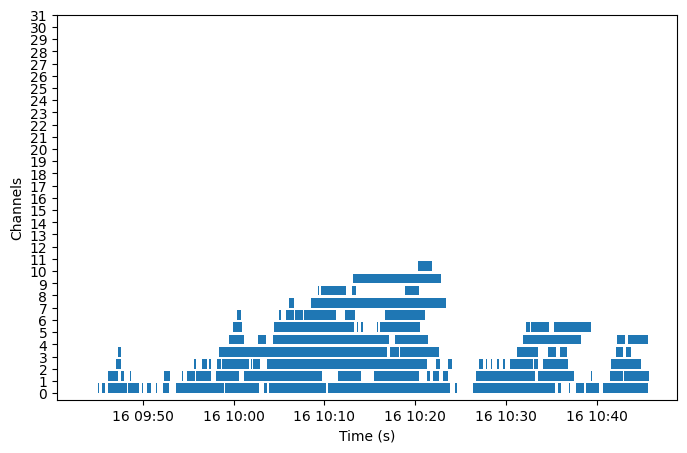

In [22]:
# Create a plot where the y axis is a list of 32 "channels" and the x axis is time.
# Create a horizontal bar for each query, from start time to end time, in the lowest available channel.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
channels = [[] for _ in range(32)]

run_id = results_df[
    (results_df["pct_heavy"] == 25)
    & (results_df["mean_interarrival"] == 30)
    & (results_df["rpu"] == 8)
]["last_run_id"].values[0]
trace = Trace(run_id)
start_times = trace.arrival_times()
end_times = trace.completion_times()
latencies_df = pd.DataFrame(
    {
        "start_time": start_times,
        "end_time": end_times,
    }
)
latencies_df = latencies_df.sort_values(by=["start_time", "end_time"])

for idx, row in latencies_df.iterrows():
    # Find the lowest available channel
    for i in range(32):
        if all(row["start_time"] >= end_time for _, end_time in channels[i]):
            channels[i].append((row["start_time"], row["end_time"]))
            ax.broken_barh(
                [(row["start_time"], row["end_time"] - row["start_time"])],
                (i, 0.8),
                facecolors="tab:blue",
            )
            break
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channels")
ax.set_yticks(range(32))
ax.set_yticklabels(range(32))
plt.show()